In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
FILE = 'C:\\Users\\qiany\\Desktop\\EXOPLANET ARCHIVE2.csv'

In [4]:
rough_data = np.genfromtxt(FILE, dtype='float', delimiter=',',skip_header=40)

In [5]:
def is_valid(number):

    try:
        float(number)
    
        if np.abs(float(number)) >= 0:
            return True 
        return False 

    except ValueError:
    
        return False

In [6]:
def read_text(rough_data):
    #period:1 
    #radius:5 upper_unc:6 lower_unc:7 
    #mass:9
    #flux:13 upper_unc:14 lower_unc:15
    #equ_temperature:17 upper_unc:18 lower_unc:19
    #efc_temperature:21 upper_unc:22 lower_unc:23
    #s_mass:25 upper_unc:26 lower_unc:27
    #metal:29 upper_unc:30 lower_unc:31

    data = np.zeros((0, 20))
    for i in range(0, len(rough_data[:, 0])):
        if (is_valid(rough_data[i, 1]) 
            and is_valid(rough_data[i, 5]) and is_valid(rough_data[i, 6]) and is_valid(rough_data[i, 7]) 
            and is_valid(rough_data[i,9]) 
            and is_valid(rough_data[i, 13]) and is_valid(rough_data[i,14]) and is_valid(rough_data[i,15])
            and is_valid(rough_data[i,17]) and is_valid(rough_data[i,18]) and is_valid(rough_data[i,19])
            and is_valid(rough_data[i,21]) and is_valid(rough_data[i,22]) and is_valid(rough_data[i,23]) 
            and is_valid(rough_data[i,25]) and is_valid(rough_data[i,26]) and is_valid(rough_data[i,27])
            and is_valid(rough_data[i,29]) and is_valid(rough_data[i,30]) and is_valid(rough_data[i,31])):
            temp = np.array([float(rough_data[i, 1]), float(rough_data[i, 5]), float(rough_data[i, 6]), float(rough_data[i, 7]), float(rough_data[i, 9]),float(rough_data[i, 13]), float(rough_data[i, 14]), float(rough_data[i, 15]), 
                            float(rough_data[i, 17]), float(rough_data[i, 18]),float(rough_data[i, 19]), float(rough_data[i, 21]), float(rough_data[i, 22]), float(rough_data[i, 23]), float(rough_data[i, 25]), float(rough_data[i, 26]),
                            float(rough_data[i, 27]), float(rough_data[i, 29]), float(rough_data[i, 30]), float(rough_data[i, 31])])
            data = np.vstack((data, temp))
    return data

In [7]:
def filter_text(rough_data):
    col_num=len(rough_data[0, :])
    data1 = np.zeros((0, col_num))
    data2 = np.zeros((0, col_num))
    for i in range(0, len(rough_data[:, 0])):
        if (rough_data[i, 0]<10 and rough_data[i, 4]>0.36):
            data1 = np.vstack((data1, rough_data[i, :]))
        else:
            data2 = np.vstack((data2, rough_data[i, :]))
            
    return data1, data2

In [8]:
data=read_text(rough_data)
data1,data2=filter_text(data)

In [9]:
print(data)

[[ 8.4634460e+00  4.2733591e-01  2.5872110e-02 ...  1.0000000e-02
   6.0000000e-02 -6.0000000e-02]
 [ 1.8859023e+01  2.4890756e-01  1.6058550e-02 ...  1.0000000e-02
   6.0000000e-02 -6.0000000e-02]
 [ 6.7183700e+00  5.7000000e-01  6.0000000e-02 ...  0.0000000e+00
   2.0000000e-01 -2.0000000e-01]
 ...
 [ 6.0012700e+00  1.8226457e-01  6.1557800e-03 ... -4.7000000e-01
   8.0000000e-02 -8.0000000e-02]
 [ 2.8641424e+00  1.3730000e+00  2.6000000e-02 ...  4.3200000e-01
   5.7000000e-02 -5.7000000e-02]
 [ 6.2678399e+00  1.8011450e-01  4.1484600e-03 ...  9.0000000e-02
   4.0000000e-02 -4.0000000e-02]]


In [10]:
print(data1)

[[ 6.180235    1.051       0.044      ...  0.141       0.082
  -0.085     ]
 [ 1.744579    1.47        0.1        ...  0.35        0.1
  -0.1       ]
 [ 3.65281514  1.135       0.048      ...  0.294       0.08
  -0.08      ]
 ...
 [ 1.36002939  1.21        0.02       ... -0.1         0.1
  -0.11      ]
 [ 3.4252602   1.2         0.06       ...  0.14        0.19
  -0.19      ]
 [ 2.8641424   1.373       0.026      ...  0.432       0.057
  -0.057     ]]


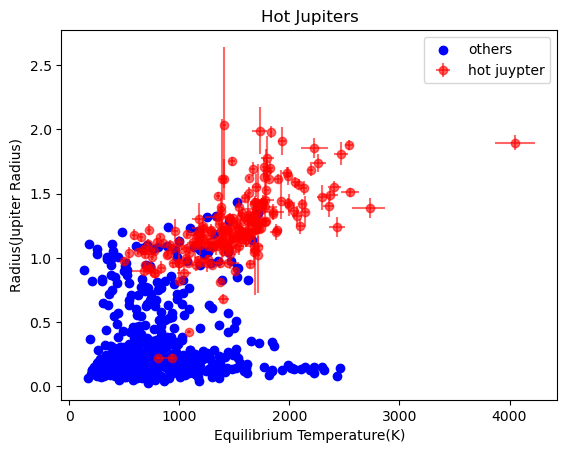

In [16]:
#period:0
#radius:1 upper_unc:2 lower_unc:3 
#mass:4
#flux:5 upper_unc:6 lower_unc:7
#equ_temperature:8 upper_unc:9 lower_unc:10
#efc_temperature:11 upper_unc:12 lower_unc:13
#s_mass:14 upper_unc:15 lower_unc:16
#metal:17 upper_unc:18 lower_unc:19

radius1=data1[:,1]
dr_up=data1[:,2]
dr_low=data1[:,3]
eq_temper1=data1[:,8]
deqt_up=data1[:,9]
deqt_low=data1[:,10] 

radius2=data2[:,1]
eq_temper2=data2[:,8]

plt.scatter(eq_temper2, radius2, color="blue", label="others")

plt.errorbar(eq_temper1, radius1, 
             xerr=[np.abs(deqt_low), np.abs(deqt_up)],
             yerr=[np.abs(dr_low), np.abs(dr_up)], 
             fmt='o', alpha=0.6, color="red", label="hot juypter")
            


plt.title('Hot Jupiters')
plt.xlabel('Equilibrium Temperature(K)')
plt.ylabel('Radius(Jupiter Radius)')
plt.legend()

plt.show()

In [19]:
metal1 = data1[:,17]
efc_temper1 = data1[:,11]

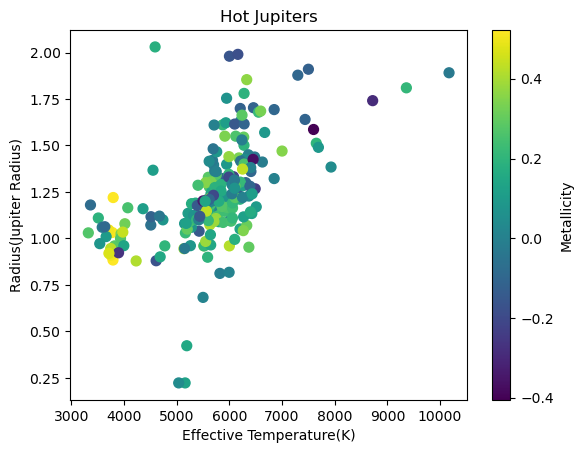

In [27]:
plt.scatter(efc_temper1, radius1, c=metal1, s=50)

plt.title('Hot Jupiters')
plt.xlabel('Effective Temperature(K)')
plt.ylabel('Radius(Jupiter Radius)')
cbar = plt.colorbar() 
cbar.set_label('Metallicity')